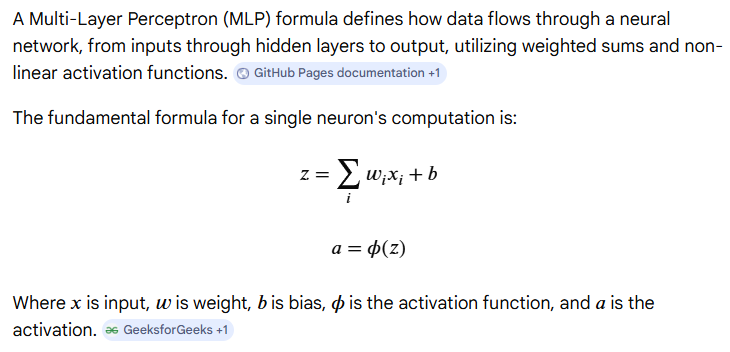

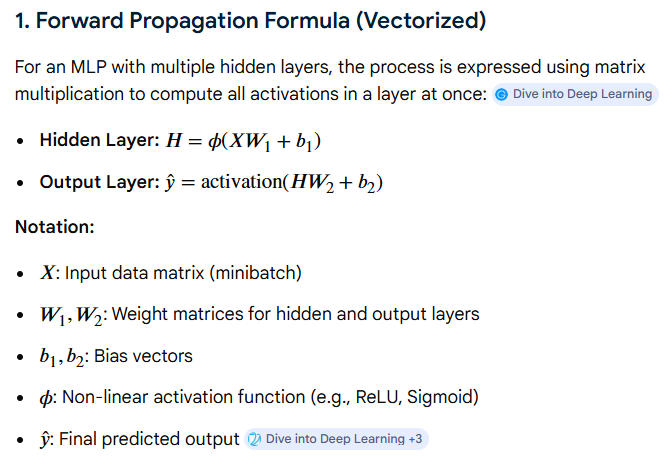

In [9]:
# File Augmentation

import pandas as pd
import numpy as np
import os

# Folder containing your 3 CSV files
# /BMDATA_20220808_121641.csv
input_folder = r"/content/inputFolder"
output_folder = r"/content/outputFolder"

os.makedirs(output_folder, exist_ok=True)

files = [f for f in os.listdir(input_folder) if f.endswith(".csv")]

def augment_data(df):
    data = df.copy()

    # 1. Add noise
    noise = np.random.normal(0, 0.01, data.shape)
    data = data + noise

    # 2. Scaling
    scale = np.random.uniform(0.9, 1.1)
    data = data * scale

    # 3. Row shifting (time shift)
    shift = np.random.randint(1, 10)
    data = pd.DataFrame(np.roll(data.values, shift, axis=0), columns=df.columns)

    return data

file_count = 0

for file in files:
    df = pd.read_csv(os.path.join(input_folder, file))

    for i in range(1000):  # 1000 variations per file → 3 × 1000 = 3000
        augmented_df = augment_data(df)

        output_name = f"{file.replace('.csv','')}_aug_{i}.csv"
        augmented_df.to_csv(os.path.join(output_folder, output_name), index=False)

        file_count += 1

print(f"Generated {file_count} augmented CSV files.")

Generated 3000 augmented CSV files.


In [10]:
import os

input_folder = r"/content/inputFolder"
print(f"Contents of {input_folder}:")
for item in os.listdir(input_folder):
    print(item)


Contents of /content/inputFolder:
BMDATA_20220809_152751.csv
BMDATA_20220808_121641.csv
BMDATA_20220808_122013.csv


In [11]:
# Step 2: #Load and read eeg signal file contains 19 parts of points
# Keep .csv files but create index (lightweight)

import numpy as np
import pandas as pd

import os

#path to read BM_Data EEG Signals which contains 300 .csv files
folder_path = r"/content/outputFolder"

data_dict = {}

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        data_dict[file] = pd.read_csv(file_path)

'''
BMDATA_20220808_121641
BMDATA_20220808_122013
BMDATA_20220809_152751
'''

#Read CSV data
#/BMDATA_20220808_122013.csv
#/BMDATA_20220808_122013.csv
#eeg_signal = pd.read_csv('/BMDATA_20220808_122013.csv')

'\nBMDATA_20220808_121641\nBMDATA_20220808_122013\nBMDATA_20220809_152751\n'

In [12]:
# Loop all 3000 .csv files
# Save each result separately
# BMDATA_<timestamp>_aug_<i>.csv
# Fast Fourier Transform (FFT)
# Converting eeg_signal in (voltage units) to eeg_signal in (frequency units)
# Need to discover how to pass all eeg_signal numpy data into the FFT calc

import numpy as np
from scipy.fft import fft, fftfreq

base_names = [
    "BMDATA_20220809_152751",
    "BMDATA_20220808_121641",
    "BMDATA_20220808_122013"
]

# /content/fftOutputs
output_folder = "/content/fftOutputs"
os.makedirs(output_folder, exist_ok=True)

for base in base_names:
    for i in range(1000):  # assuming 0–999

        key = f"{base}_aug_{i}.csv"

        # get dataframe from your dictionary
        eeg_signal = data_dict[key]

        all_magnitudes = []

        def gaussian(eeg_signal_channel):
          noise_factor = 0.01
          augmented = eeg_signal_channel + noise_factor * np.random.randn(*eeg_signal_channel.shape)

          return augmented

        def fft_analysis(augmented_eeg_signal_channel, fs = 250):

          N = len(augmented_eeg_signal_channel)
          yf = fft(augmented_eeg_signal_channel) #Complex FFT result
          xf = fftfreq(N, 1/fs) #Frequency axis

          # Take positive frequencies
          xf_positive = xf[:N//2] #Frequency
          yf_positive = yf[:N//2] #Strength

          #Store magnitude separately
          magnitude = np.abs(yf_positive)

          return xf_positive, yf_positive, magnitude

        # FFT per channel (feature extraction by converting voltage signals to frequency)
        # Calling FFT to convert Voltage to Frequency
        # Need to verify if all is converted to frequency and stored in the array matrix_signal
        # Process multiple EEG segments

        for column_name in eeg_signal.columns:

          eeg_channel_data = eeg_signal[column_name].values
          augmented = gaussian(eeg_channel_data)
          xf_positive, yf_positive, magnitude = fft_analysis(augmented)
          all_magnitudes.append(magnitude)

        all_magnitudes = np.array(all_magnitudes)
        # print(all_magnitudes) #To test the output of result

        # Reshape all_magnitudes to 2D array with 19 columns (channels) and 500 rows (frequency bins)
        # Transpose the array to have frequency bins as rows and channels as columns
        vertical_data = all_magnitudes.T

        # Save with clear naming
        save_name = f"fft_{base}_aug_{i}.csv"
        save_path = os.path.join(output_folder, save_name)

        # Save all_magnitudes to .csv
        np.savetxt(save_path, vertical_data, fmt='%.4f', delimiter=',')

In [13]:
# Convert eeg_signal_freq.csv in numpy without header to dataframe
# Scale it to 3000 files
# fft stands for Fast Fourier Transform
path_df = r"/content/fftOutputs"

fft_dict = {}

for file in os.listdir(path_df):
    if file.endswith(".csv"):
        file_path = os.path.join(path_df, file)
        fft_dict[file] = pd.read_csv(file_path, header=None, names=['P4', 'O2', 'P8', 'T8', 'C4', 'Cz', 'Fz', 'F4', 'Fp2', 'F8', 'Fp1', 'F7', 'F3', 'C3', 'T7', 'P7', 'P3', 'O1', 'Pz'])

In [14]:
# Checking if all keys exist
print(len(fft_dict))

3000


In [15]:
# Checking 1 sample
print(fft_dict["fft_BMDATA_20220809_152751_aug_0.csv"].shape)

(500, 19)


In [16]:
# Simplifying codes into pipeline
# Rewrite everything so it works on 1 dataframe input → one result output
# Delta (0.5-4Hz), Theta (4-8 Hz), Alpha (8-13Hz), Beta (13-30 Hz) and Gamma (.30Hz)

def process_eeg_dataframe(df):
    import numpy as np

    columnlist = df[['P4','O2','P8','T8','C4','Cz','Fz','F4','Fp2','F8',
                     'Fp1','F7','F3','C3','T7','P7','P3','O1','Pz']]

    leftList  = df[['Fp1','F7','F3','C3','T7','P7','P3','O1']]
    rightList = df[['Fp2','F8','F4','C4','T8','P8','P4','O2']]

    # Local lists (IMPORTANT: no globals)
    delta, theta, alpha, beta, high_beta, artefact, noise = ([] for _ in range(7))
    thetaLeft, othersLeft, thetaRight, othersRight = ([] for _ in range(4))

    # --- Band split ---
    for col in columnlist.columns:
        for x in columnlist[col]:
            if 0.5 <= x <= 3.5:
                delta.append(x)
            elif 3.5 < x <= 7.5:
                theta.append(x)
            elif 7.5 < x <= 12:
                alpha.append(x)
            elif 12 < x <= 20:
                beta.append(x)
            elif 20 < x <= 32:
                high_beta.append(x)
            elif x < 0.5:
                artefact.append(x)
            else:
                noise.append(x)

    for col in leftList.columns:
        for x in leftList[col]:
            (thetaLeft if 3.5 <= x <= 7.5 else othersLeft).append(x)

    for col in rightList.columns:
        for x in rightList[col]:
            (thetaRight if 3.5 <= x <= 7.5 else othersRight).append(x)

    # --- Convert to arrays ---
    arrDelta = np.array(delta)
    arrTheta = np.array(theta)
    arrAlpha = np.array(alpha)
    arrBeta = np.array(beta)
    arrHigh = np.array(high_beta)

    arrThetaLeft  = np.array(thetaLeft)
    arrThetaRight = np.array(thetaRight)

    # --- RMS ---
    def rms(arr):
        return np.sqrt(np.mean(arr**2)) if len(arr) > 0 else 0.0

    Delta_rms = rms(arrDelta)
    Theta_rms = rms(arrTheta)
    Alpha_rms = rms(arrAlpha)
    Beta_rms  = rms(arrBeta)
    High_rms  = rms(arrHigh)

    thetaLeft_rms  = rms(arrThetaLeft)
    thetaRight_rms = rms(arrThetaRight)

    # --- Ratios ---
    ratioADHD = Theta_rms / (Theta_rms + Beta_rms + High_rms) if (Theta_rms + Beta_rms + High_rms) else 0.0
    ratioAutism = Alpha_rms / (Alpha_rms + Beta_rms + High_rms) if (Alpha_rms + Beta_rms + High_rms) else 0.0
    ratioDyslexia = thetaLeft_rms / thetaRight_rms if thetaRight_rms else 0.0

    return {
        "ADHD_ratio": ratioADHD,
        "Autism_ratio": ratioAutism,
        "Dyslexia_ratio": ratioDyslexia
    }

# Loop over 3000 files
results = {}

for filename, df in fft_dict.items():
    result = process_eeg_dataframe(df)
    results[filename] = result

In [17]:
# Checking
print(len(results))

3000


In [18]:
# Checking 1 sample
print(results)

{'fft_BMDATA_20220808_122013_aug_69.csv': {'ADHD_ratio': np.float64(0.12139689614747351), 'Autism_ratio': np.float64(0.1869196028236285), 'Dyslexia_ratio': np.float64(1.075082079037024)}, 'fft_BMDATA_20220808_121641_aug_418.csv': {'ADHD_ratio': np.float64(0.13069288828117231), 'Autism_ratio': np.float64(0.19985800460617514), 'Dyslexia_ratio': np.float64(1.0801272631707315)}, 'fft_BMDATA_20220808_121641_aug_609.csv': {'ADHD_ratio': np.float64(0.13062261797824382), 'Autism_ratio': np.float64(0.20000944057469652), 'Dyslexia_ratio': np.float64(1.080542171785338)}, 'fft_BMDATA_20220808_122013_aug_417.csv': {'ADHD_ratio': np.float64(0.12184315408305744), 'Autism_ratio': np.float64(0.18708275555606035), 'Dyslexia_ratio': np.float64(1.0884776340756628)}, 'fft_BMDATA_20220808_122013_aug_154.csv': {'ADHD_ratio': np.float64(0.12322792499230863), 'Autism_ratio': np.float64(0.1883659551036132), 'Dyslexia_ratio': np.float64(1.0782290470203237)}, 'fft_BMDATA_20220808_121641_aug_232.csv': {'ADHD_ratio

In [19]:
# Save all results into 1 csv
# /content
import pandas as pd

rows = []

for filename, df in fft_dict.items():
    result["filename"] = filename
    result = process_eeg_dataframe(df)

    rows.append(result)

final_df = pd.DataFrame(rows)
final_df.to_csv("/content/all_results.csv", index=False)

In [20]:
# Checking output
print(final_df.keys())

Index(['ADHD_ratio', 'Autism_ratio', 'Dyslexia_ratio', 'filename'], dtype='object')


In [21]:
# Interating with values (  .items())
# Checking if the logic is TRUE by printing the results
for key, value in final_df.items():
    print(f"{key}: {value}")


ADHD_ratio: 0       0.121397
1       0.130693
2       0.130623
3       0.121843
4       0.123228
          ...   
2995    0.121418
2996    0.113419
2997    0.131888
2998    0.120599
2999    0.133013
Name: ADHD_ratio, Length: 3000, dtype: float64
Autism_ratio: 0       0.186920
1       0.199858
2       0.200009
3       0.187083
4       0.188366
          ...   
2995    0.186817
2996    0.185157
2997    0.196259
2998    0.188010
2999    0.197608
Name: Autism_ratio, Length: 3000, dtype: float64
Dyslexia_ratio: 0       1.075082
1       1.080127
2       1.080542
3       1.088478
4       1.078229
          ...   
2995    1.077098
2996    1.077694
2997    1.010368
2998    1.063007
2999    1.008869
Name: Dyslexia_ratio, Length: 3000, dtype: float64
filename: 0       fft_BMDATA_20220808_121641_aug_418.csv
1       fft_BMDATA_20220808_121641_aug_609.csv
2       fft_BMDATA_20220808_122013_aug_417.csv
3       fft_BMDATA_20220808_122013_aug_154.csv
4       fft_BMDATA_20220808_121641_aug_232.csv
     

In [22]:
# --- Helper functions & Dataset Loading/Preparation ---

# Load the final_df which contains the calculated ratios from previous cells
# Assuming 'final_df' was saved to '/content/all_results.csv'
final_df = pd.read_csv('/content/all_results.csv')

# Define the classification function to return a single integer label per sample
def classify_row_diagnosis(row):
    # Prioritize diagnosis: ADHD > Autism > Dyslexia
    if row['ADHD_ratio'] > 2:
        return 0  # Label for ADHD
    elif row['Autism_ratio'] < 1:
        return 1  # Label for Autism
    elif row['Dyslexia_ratio'] > 1:
        return 2  # Label for Dyslexia
    else:
        return 3  # Label for 'Normal' or 'No specific diagnosis'

# Apply the classification function to each row to get the target labels (y)
final_df['diagnosis_label'] = final_df.apply(classify_row_diagnosis, axis=1)

# Prepare features (X) and labels (y)
X = final_df[['ADHD_ratio', 'Autism_ratio', 'Dyslexia_ratio']].values
y = final_df['diagnosis_label'].values

print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")
print(f"Sample labels (y): {y[:10]}") # Display first 10 labels for verification


Shape of features (X): (3000, 3)
Shape of labels (y): (3000,)
Sample labels (y): [1 1 1 1 1 1 1 1 1 1]


In [23]:
results_df = pd.DataFrame(X, columns=['ADHD_ratio', 'Autism_ratio', 'Dyslexia_ratio'])
results_df['diagnosis_label'] = y

results_df.to_csv('/content/features_and_labels.csv', index=False)
print("Features and labels saved to '/content/features_and_labels.csv'")

Features and labels saved to '/content/features_and_labels.csv'


In [25]:
# Display the first few rows of the saved CSV to verify
# display(pd.read_csv('/content/features_and_labels.csv').head())

mlp_df = pd.read_csv('/content/features_and_labels_updated.csv')
display(mlp_df.head())

,ADHD_ratio,Autism_ratio,Dyslexia_ratio,diagnosis_label
0,0.112294,1.184439,1.075082,2
1,0.120068,2.187553,1.080127,2
2,0.120782,0.187009,1.080542,1
3,2.122244,1.186738,1.088478,0
4,0.130874,2.198594,1.078229,2


In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

# ----------------------------
# Dataset with extra features
# ----------------------------
X = mlp_df[['ADHD_ratio', 'Autism_ratio', 'Dyslexia_ratio']]

X = X.to_numpy()
y = mlp_df[['diagnosis_label']].values

# Split the data into training and testing sets

# 1. Scale data (highly recommended for L2 regularization)
# Introduce L2 regularization to reduce overfitting
# Scale features
scaler = StandardScaler()
# 2. Initialize Ridge with regularization strength (alpha)
#scalerRidge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

X = scaler.fit_transform(X)

# Fit a Ridge regression model with L2 regularization
#ridge_model = Ridge(alpha=1.0)  # You can adjust the alpha value for regularization strength
#ridge_model.fit(X_train, y_train)

# Make predictions on the training data with Ridge
#y_train_pred_ridge = ridge_model.predict(X_train)

# Make predictions on the testing data with Ridge
#y_test_pred_ridge = ridge_model.predict(X_test)

# Calculate the Mean Squared Error (MSE) for Ridge on training and testing data
#train_mse_ridge = mean_squared_error(y_train, y_train_pred_ridge)
#test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#for arch in architectures:
  # -------------------
  # MLP Model
  # -------------------
  # Hidden Layer
  #  (8,),          # 1 hidden layer with 8 neurons
  #  (32,),         # 1 hidden layer with 32 neurons
  #  (32,16),       # 2 hidden layers
  #  (64,32,16),    # 3 hidden layers
  # Activation function: {'relu', 'identity', 'logistic', 'tanh'}
mlp = MLPClassifier(hidden_layer_sizes=(16,), activation='relu', alpha=0.01,
                    early_stopping=True,max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# -------------------
# Evaluation
# -------------------
y_pred = mlp.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["ADHD", "Autism", "Dyslexia"]))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

        ADHD       0.97      0.99      0.98       177
      Autism       0.99      1.00      0.99       235
    Dyslexia       1.00      0.96      0.98       188

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



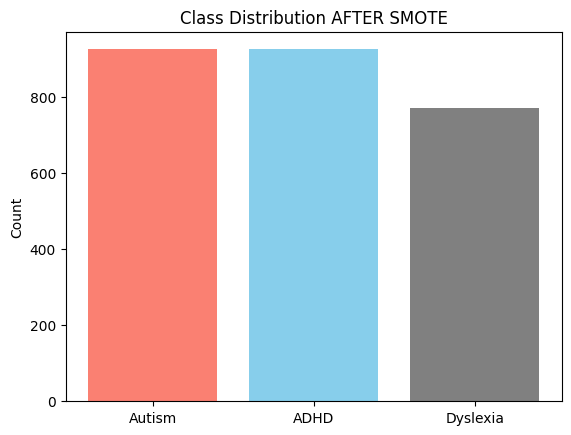

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import SMOTE
import seaborn as sns

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Convert y_train_sm to a Pandas Series to use value_counts()
class_counts = pd.Series(y_train_sm).value_counts()

plt.bar(class_counts.index, class_counts.values,
        color=['skyblue','salmon', 'grey'])
# Use the actual class indices from the counts for xticks and provide the labels
plt.xticks(class_counts.index, ['ADHD', 'Autism', 'Dyslexia'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

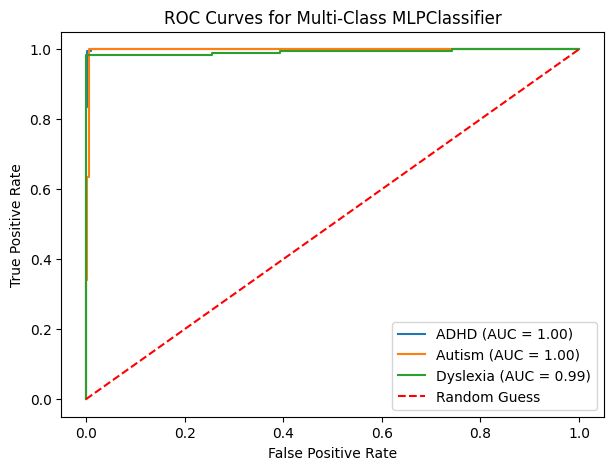

In [34]:
# Compute Receiver-Operating Characteristic Curve (ROC) and Area Under Curve (AUC) for MLPClassifier
# Evaluate model quality
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt # Added import for plt

# It's important to get prediction probabilities for ROC curves, not just class labels
# Assuming mlp, X_test, y_test are available from previous cells.
y_pred_proba = mlp.predict_proba(X_test)
y_true_flat = y_test.ravel() # Ensure y_test is a 1D array for comparison

plt.figure(figsize=(7, 5))

# Define class names for plotting
# Assuming classes are 0, 1, 2 based on previous 'diagnosis_label' creation
class_names = ["ADHD", "Autism", "Dyslexia"]
n_classes = len(class_names)

# Plotting ROC Curve for each class in MLPClassifier (One-vs-Rest strategy)
for i in range(n_classes):
    # Convert true labels to binary (1 for current class, 0 for others)
    y_true_binary = (y_true_flat == i).astype(int)
    # Get predicted probabilities for the current class
    y_score_class = y_pred_proba[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_score_class)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class MLPClassifier')
plt.legend()
plt.show()

Accuracy AFTER SMOTE: 98.67 %

Classification Report AFTER SMOTE:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       177
           1       0.99      1.00      0.99       235
           2       1.00      0.96      0.98       188

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



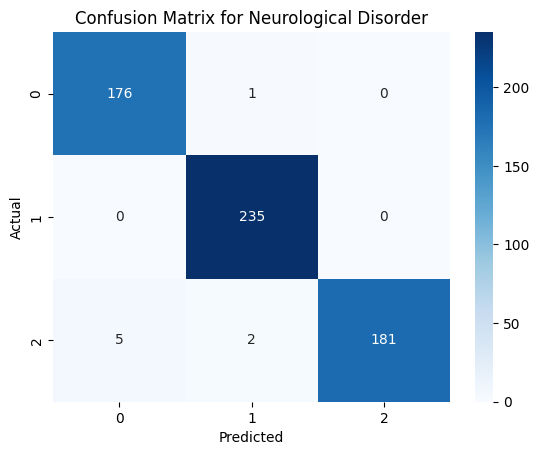

In [33]:
#Calculate classification metrics for Multi Layer Perceptron Model
#Accuracy after SMOTE

mlp.fit(X_train_sm, y_train_sm)

y_pred_sm = mlp.predict(X_test)

print("Accuracy AFTER SMOTE:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
print("Classification Report AFTER SMOTE:\n", classification_report(y_test, y_pred_sm))

sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Neurological Disorder")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()